# Notebook 03: Exploratory Data Analysis
Visual exploration of sales, profit, and business performance across time, category, region, and segment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 150
os.makedirs("../outputs/figures", exist_ok=True)

# Load cleaned data
df = pd.read_csv("../data/processed/cleaned_data.csv", encoding="latin-1")
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["YearMonth"] = df["Order Date"].dt.to_period("M")

print("Shape:", df.shape)
df.head(3)

Shape: (9994, 31)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Year,Month,Quarter,MonthName,DayOfWeek,YearMonth,DaysToShip,ProfitMargin,HighDiscount,SalesOutlier
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2016,11,4,Nov,Tuesday,2016-11,3,0.16,False,False
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2016,11,4,Nov,Tuesday,2016-11,3,0.30,False,True
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2016,6,2,Jun,Sunday,2016-06,4,0.47,False,False


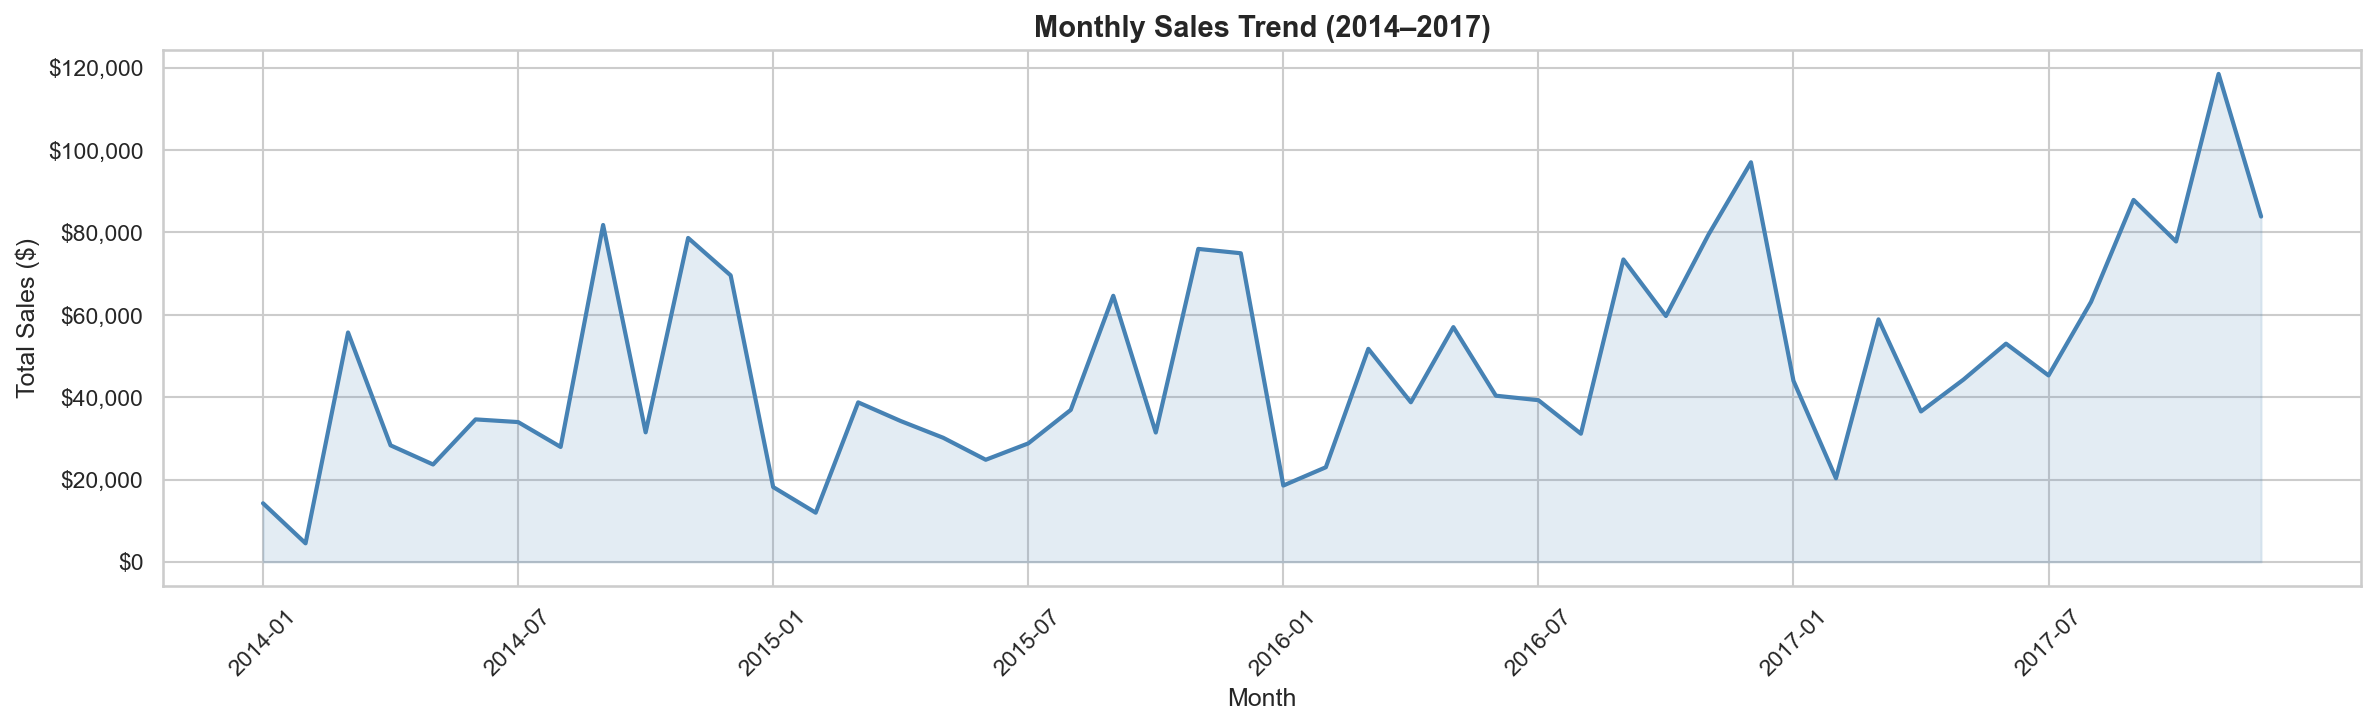

Saved.


In [2]:
# Monthly sales trend over time
monthly_sales = df.groupby("YearMonth")["Sales"].sum().reset_index()
monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_sales["YearMonth"], monthly_sales["Sales"], color="steelblue", linewidth=2)
ax.fill_between(monthly_sales["YearMonth"], monthly_sales["Sales"], alpha=0.15, color="steelblue")
ax.set_title("Monthly Sales Trend (2014–2017)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
tick_positions = list(range(0, len(monthly_sales), 6))
ax.set_xticks(tick_positions)
ax.set_xticklabels([monthly_sales["YearMonth"].iloc[i] for i in tick_positions], rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/monthly_sales_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

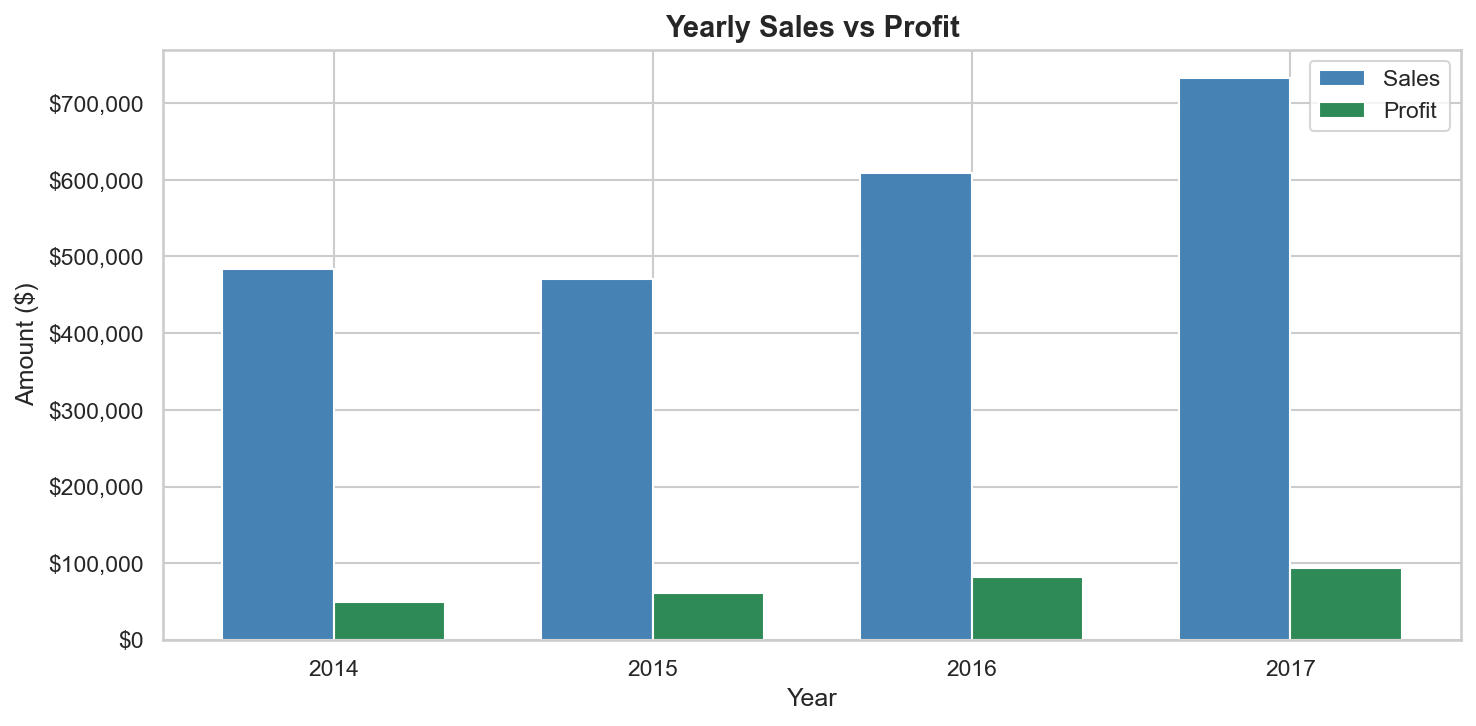

Saved.


In [3]:
# Yearly sales and profit comparison
yearly = df.groupby("Year")[["Sales", "Profit"]].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(yearly))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], yearly["Sales"], width=width, label="Sales", color="steelblue")
bars2 = ax.bar([i + width/2 for i in x], yearly["Profit"], width=width, label="Profit", color="seagreen")
ax.set_title("Yearly Sales vs Profit", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Amount ($)")
ax.set_xticks(list(x))
ax.set_xticklabels(yearly["Year"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/yearly_sales_profit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

/var/folders/bx/33dlqx6x0p39z5c4ysnz85x00000gn/T/ipykernel_92268/1490113691.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_sales, x="Sales", y="Category", ax=axes[0], palette="Blues_d")
/var/folders/bx/33dlqx6x0p39z5c4ysnz85x00000gn/T/ipykernel_92268/1490113691.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subcat_sales, x="Sales", y="Sub-Category", ax=axes[1], palette="Blues_d")


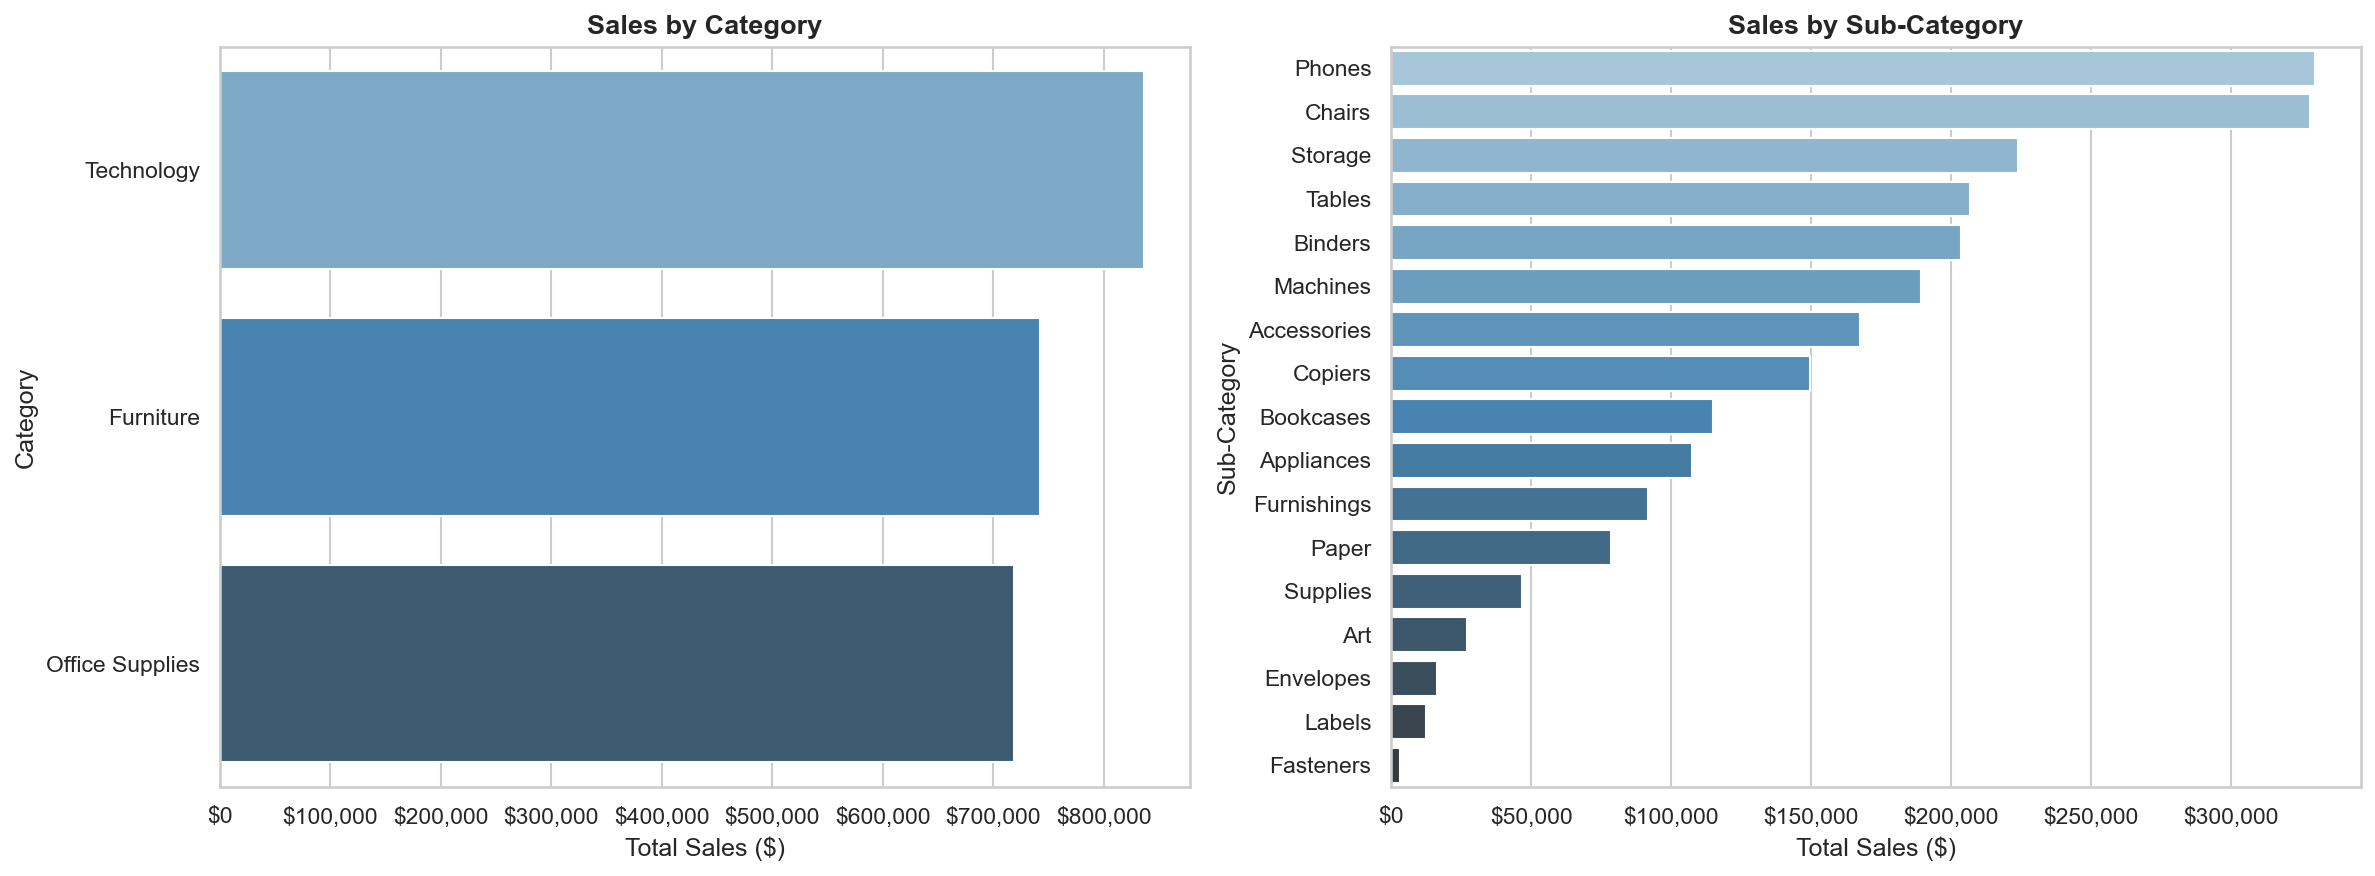

Saved.


In [4]:
# Sales by Category and Sub-Category
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False).reset_index()
subcat_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Category
sns.barplot(data=cat_sales, x="Sales", y="Category", ax=axes[0], palette="Blues_d")
axes[0].set_title("Sales by Category", fontsize=13, fontweight="bold")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[0].set_xlabel("Total Sales ($)")

# Sub-Category
sns.barplot(data=subcat_sales, x="Sales", y="Sub-Category", ax=axes[1], palette="Blues_d")
axes[1].set_title("Sales by Sub-Category", fontsize=13, fontweight="bold")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].set_xlabel("Total Sales ($)")

plt.tight_layout()
plt.savefig("../outputs/figures/sales_by_category.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

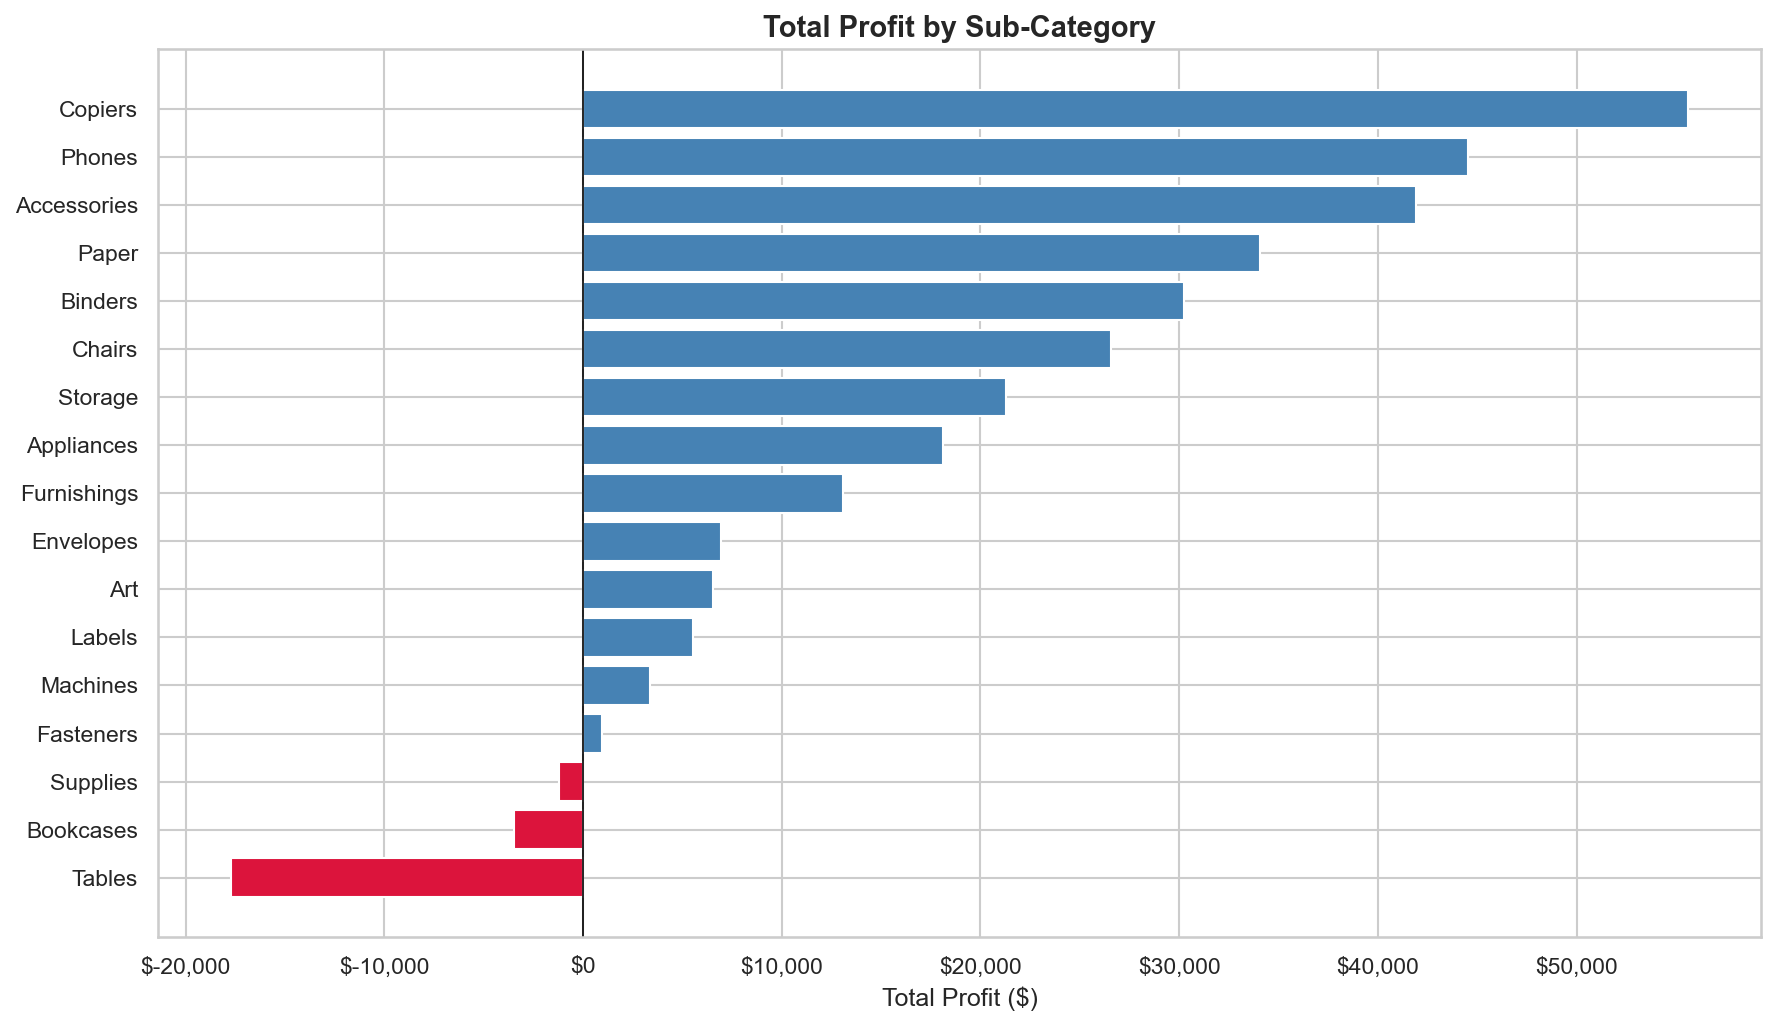

Saved.


In [5]:
# Profit by Sub-Category (highlighting losses)
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values().reset_index()
colors = ["crimson" if x < 0 else "steelblue" for x in subcat_profit["Profit"]]

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(subcat_profit["Sub-Category"], subcat_profit["Profit"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Total Profit by Sub-Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Total Profit ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../outputs/figures/profit_by_subcategory.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

/var/folders/bx/33dlqx6x0p39z5c4ysnz85x00000gn/T/ipykernel_92268/2649226946.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_sales, x="Region", y="Sales", ax=axes[0], palette="Blues_d")
/var/folders/bx/33dlqx6x0p39z5c4ysnz85x00000gn/T/ipykernel_92268/2649226946.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_sales, x="Segment", y="Sales", ax=axes[1], palette="Blues_d")


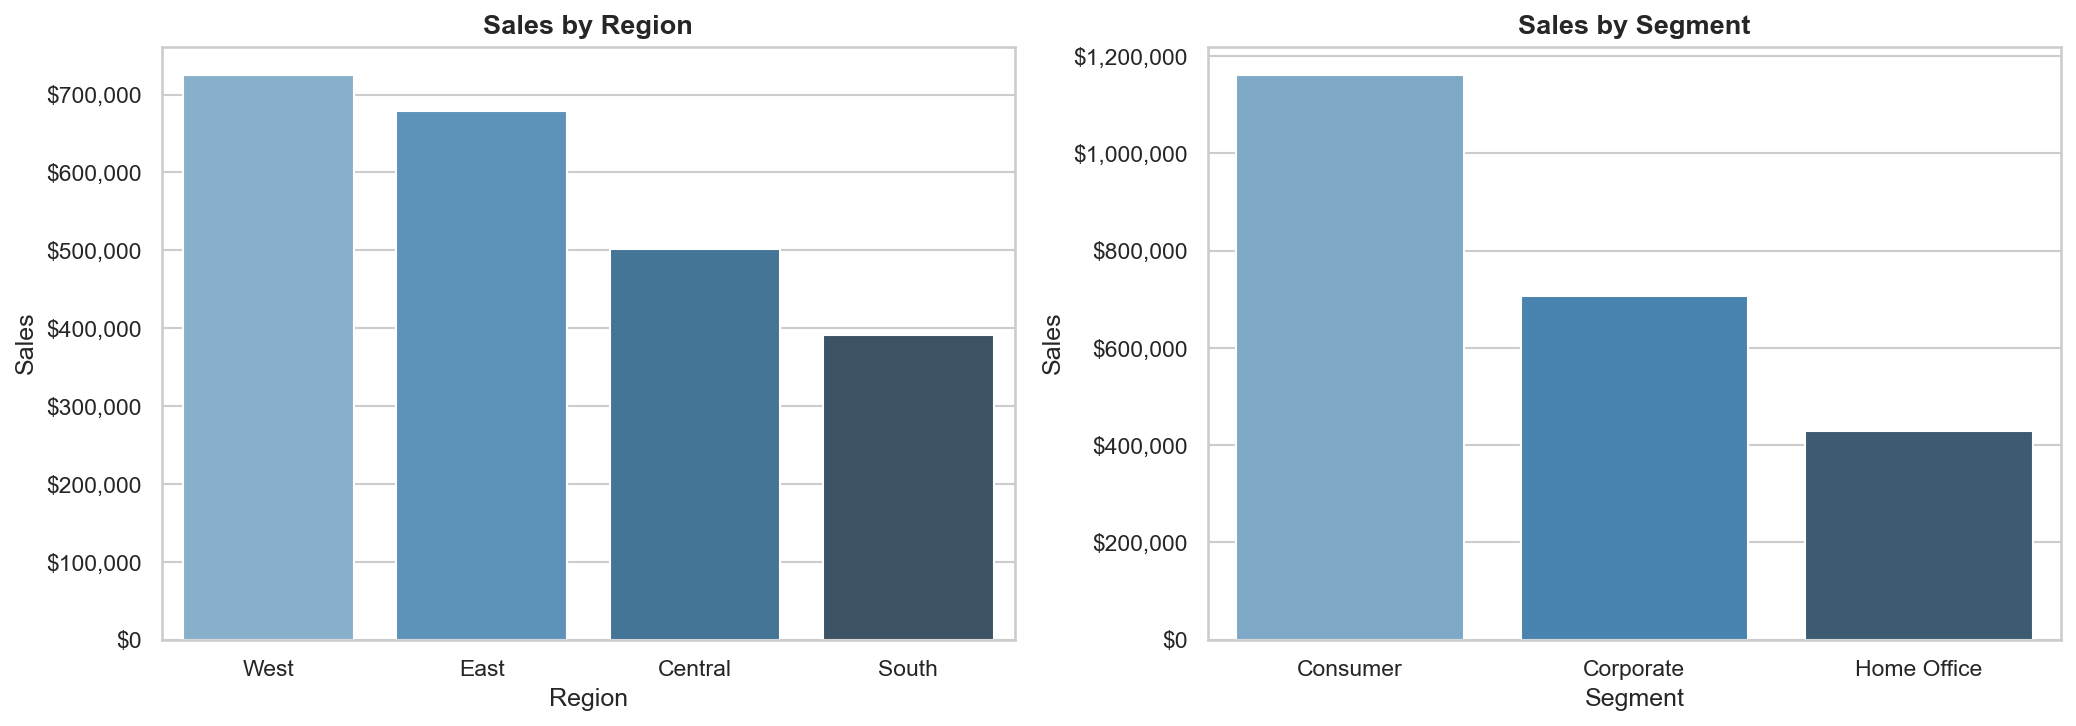

Saved.


In [6]:
# Sales by Region and Segment
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False).reset_index()
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=region_sales, x="Region", y="Sales", ax=axes[0], palette="Blues_d")
axes[0].set_title("Sales by Region", fontsize=13, fontweight="bold")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

sns.barplot(data=segment_sales, x="Segment", y="Sales", ax=axes[1], palette="Blues_d")
axes[1].set_title("Sales by Segment", fontsize=13, fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig("../outputs/figures/sales_by_region_segment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

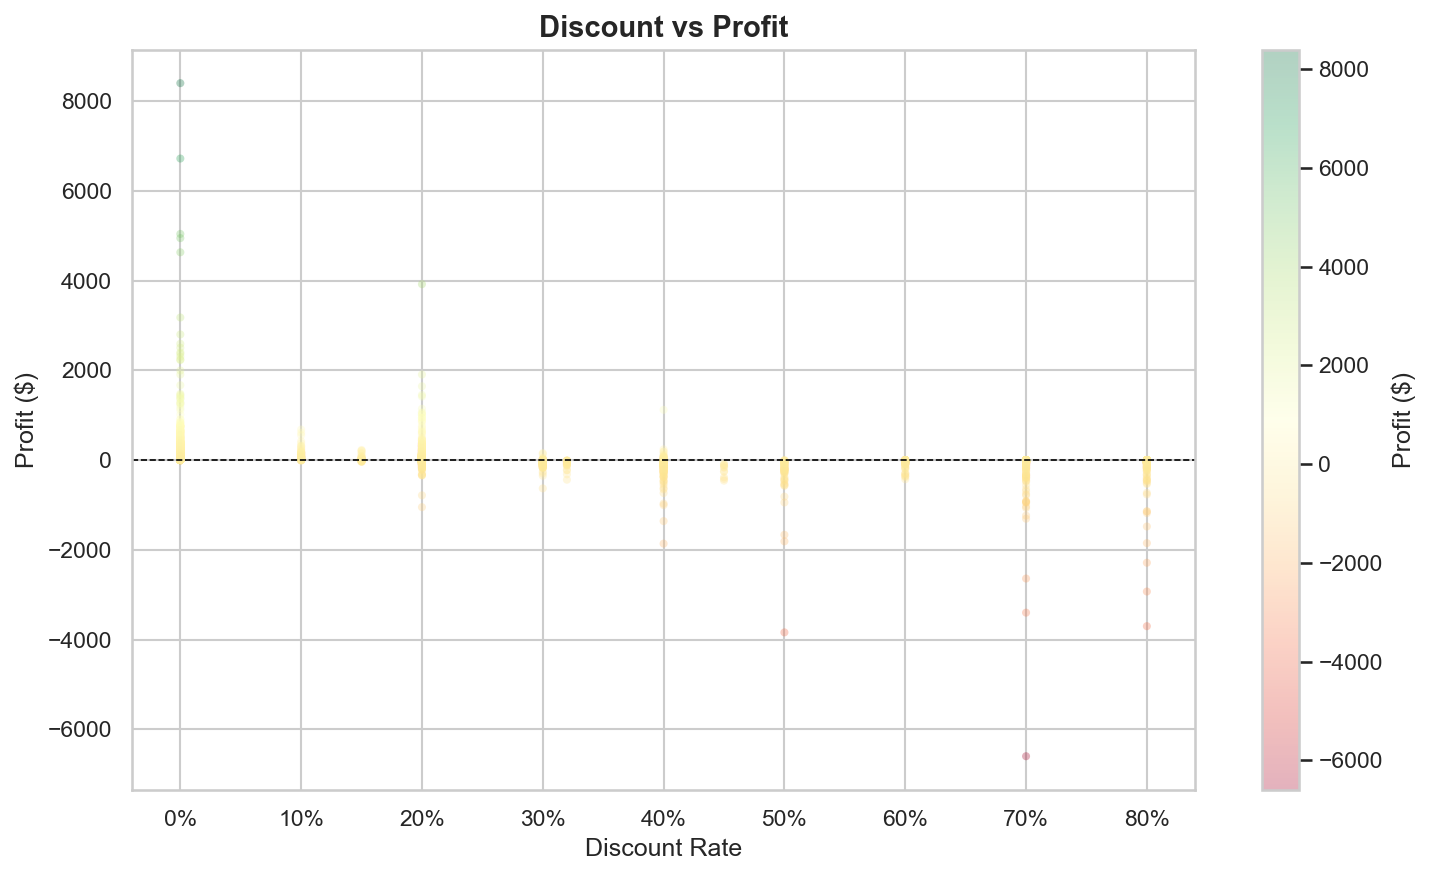

Saved.


In [7]:
# Discount vs Profit scatter plot
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df["Discount"], df["Profit"],
                     alpha=0.3, c=df["Profit"],
                     cmap="RdYlGn", edgecolors="none", s=15)
plt.colorbar(scatter, ax=ax, label="Profit ($)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Discount vs Profit", fontsize=14, fontweight="bold")
ax.set_xlabel("Discount Rate")
ax.set_ylabel("Profit ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig("../outputs/figures/discount_vs_profit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

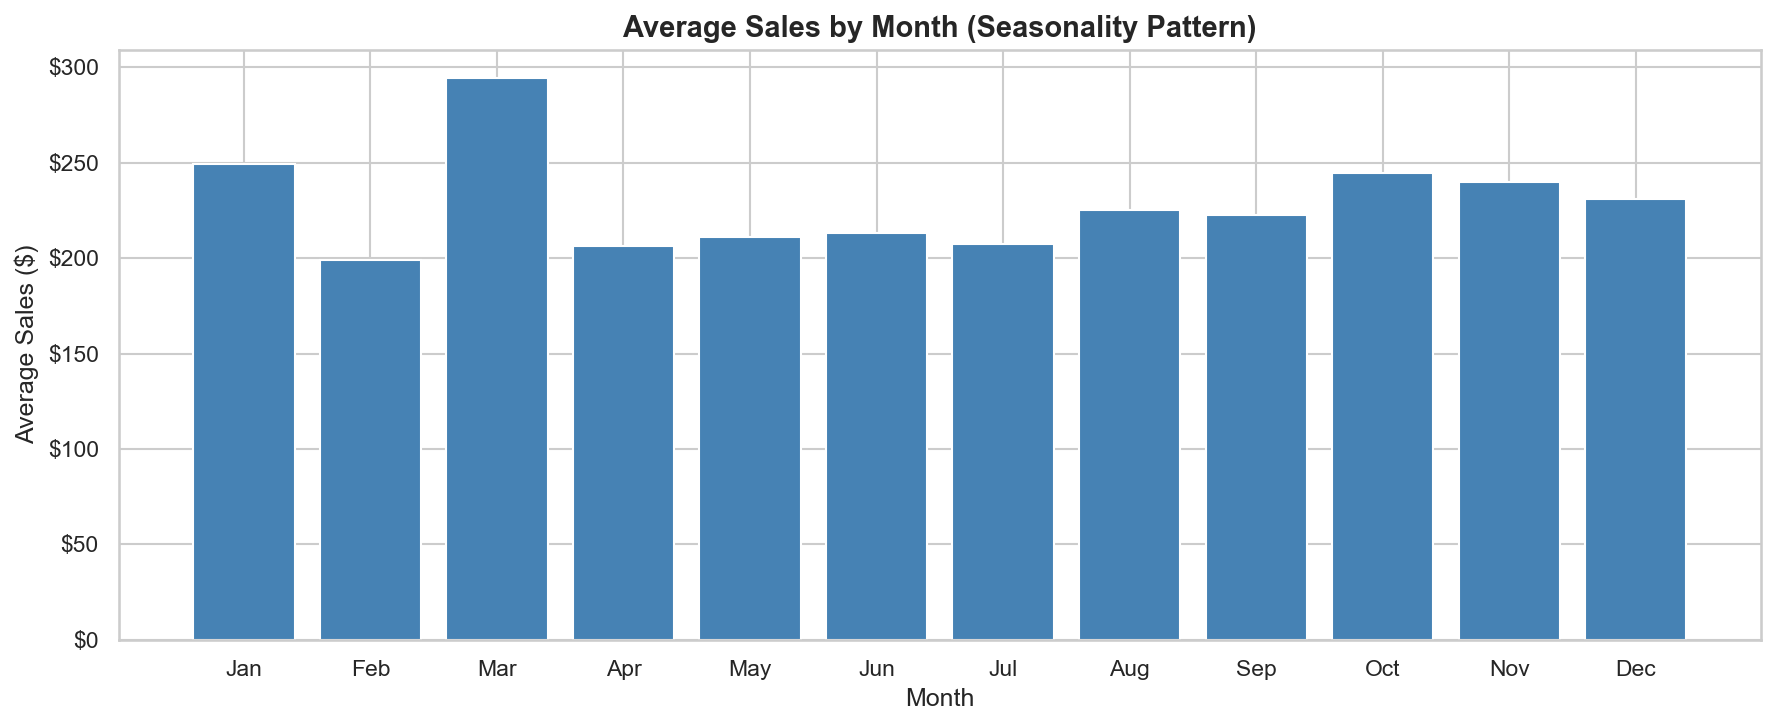

Saved.


In [8]:
# Monthly seasonality — average sales by month across all years
monthly_avg = df.groupby("Month")["Sales"].mean().reset_index()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_avg["Month"], monthly_avg["Sales"], color="steelblue", edgecolor="white")
ax.set_title("Average Sales by Month (Seasonality Pattern)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Average Sales ($)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../outputs/figures/monthly_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

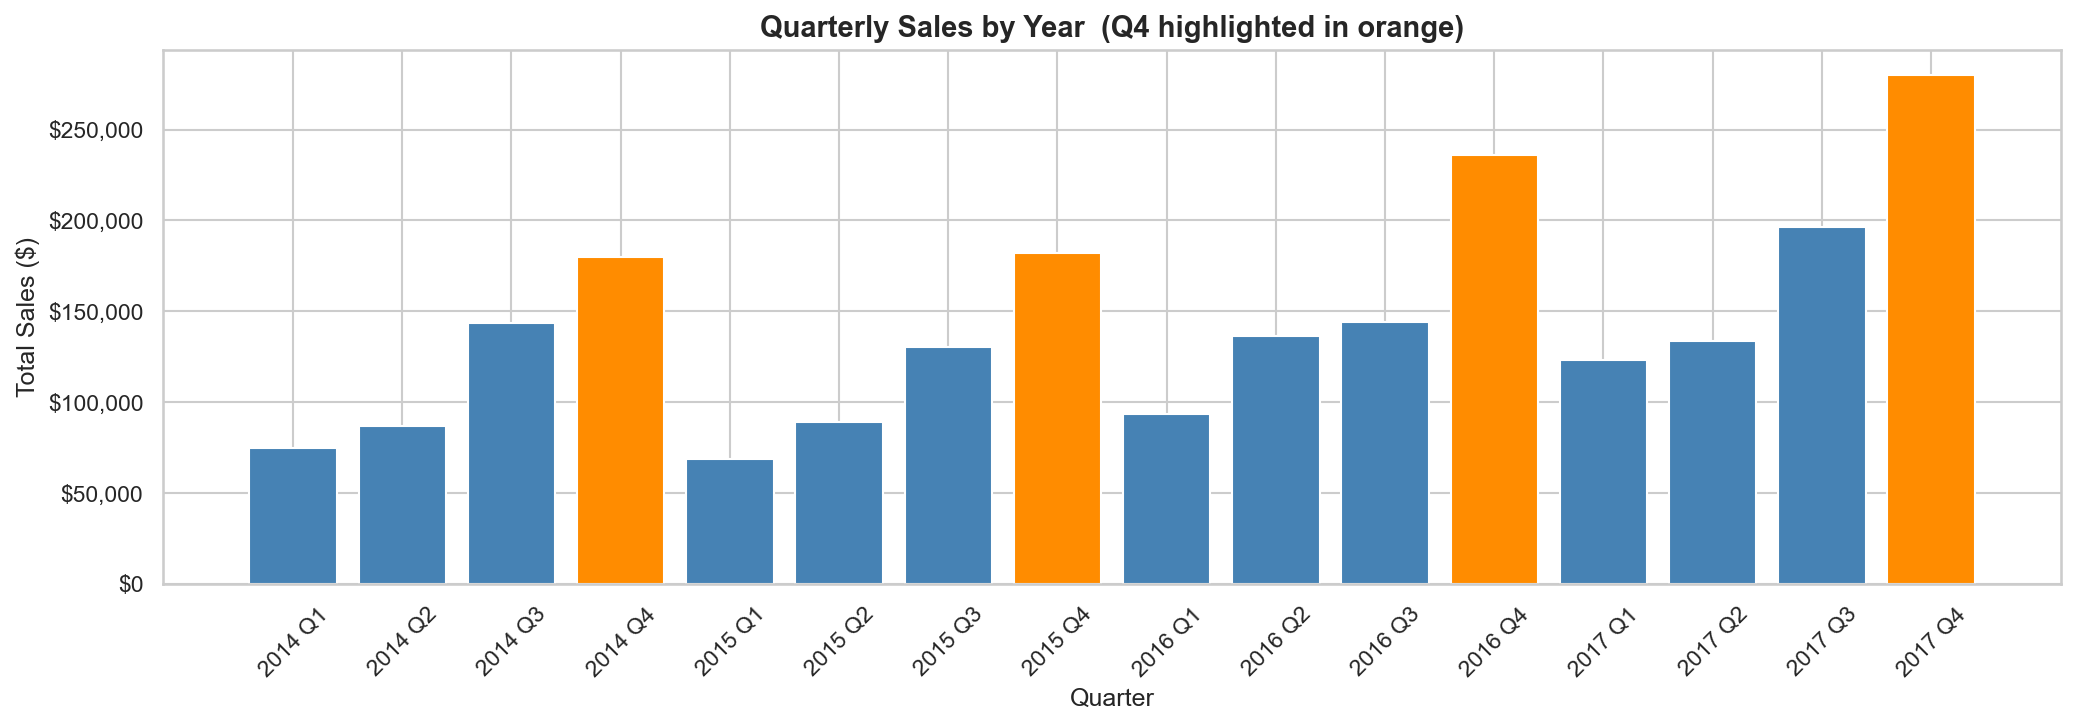

Saved.


In [9]:
# Q4 focus — sales by quarter across years
quarterly = df.groupby(["Year","Quarter"])["Sales"].sum().reset_index()
quarterly["Label"] = quarterly["Year"].astype(str) + " Q" + quarterly["Quarter"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["steelblue" if q != 4 else "darkorange" for q in quarterly["Quarter"]]
ax.bar(quarterly["Label"], quarterly["Sales"], color=colors, edgecolor="white")
ax.set_title("Quarterly Sales by Year  (Q4 highlighted in orange)", fontsize=14, fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("Total Sales ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/quarterly_sales.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [10]:
# Summary stats for EDA
print("=== EDA SUMMARY ===")
print(f"\nTotal Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Overall Profit Margin: {df['Profit'].sum()/df['Sales'].sum():.1%}")
print(f"\nBest Year by Sales: {yearly.loc[yearly['Sales'].idxmax(), 'Year']}")
print(f"Best Quarter: Q4 (consistent across all years)")
print(f"\nTop Category by Sales: {cat_sales.iloc[0]['Category']} (${cat_sales.iloc[0]['Sales']:,.0f})")
print(f"\nLoss-making Sub-Categories:")
losses = df.groupby("Sub-Category")["Profit"].sum()
print(losses[losses < 0].sort_values().round(2))

=== EDA SUMMARY ===

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.5%

Best Year by Sales: 2017
Best Quarter: Q4 (consistent across all years)

Top Category by Sales: Technology ($836,154)

Loss-making Sub-Categories:
Sub-Category
Tables      -17725.48
Bookcases    -3472.56
Supplies     -1189.10
Name: Profit, dtype: float64
